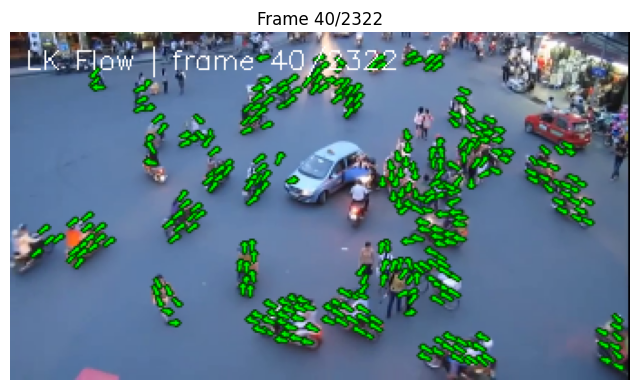

40/2322 done
Processing frame 41/2322
Processing frame 42/2322
Processing frame 43/2322
Processing frame 44/2322
Processing frame 45/2322
Processing frame 46/2322
Processing frame 47/2322
Processing frame 48/2322
Processing frame 49/2322
Done!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:

import cv2
import numpy as np
from google.colab import files
from google.colab.patches import cv2_imshow
from collections import deque
from scipy import signal
import matplotlib.pyplot as plt
from IPython.display import clear_output



def grad(blurred1,blurred2):

    Gx=np.array([[-1,0,1],
                [-2,0,2],
                [-1,0,1]])
    Gy=np.array([[-1,-2,-1],
                [0,0,0],
                [1,2,1]])
    Gt_neg=-(np.ones((3,3)).astype(np.float32))/9
    Gt_pos=(np.ones((3,3)).astype(np.float32))/9


    Ix = signal.convolve2d(blurred1, Gx, 'same') + signal.convolve2d(blurred2, Gx, 'same')
    Iy = signal.convolve2d(blurred1, Gy, 'same') + signal.convolve2d(blurred2, Gy, 'same')
    It= signal.convolve2d(blurred1,Gt_pos,'same')+signal.convolve2d(blurred2,Gt_neg,'same')

    return Ix,Iy,It

def build_pyramid(img,levels=3):
    pyramid=[img]
    for i in range(levels-1):
      smaller=cv2.pyrDown(pyramid[-1])
      pyramid.append(smaller)
    return pyramid

def lk(Ix,Iy,It,row,col,half):
    IX=[]
    IY=[]
    IT=[]
    for di in range(-half,half+1):
      for dj in range(-half,half+1):
        IX.append(Ix[row+di][col+dj])
        IY.append(Iy[row+di][col+dj])
        IT.append(It[row+di][col+dj])

    A=np.column_stack((IX,IY))
    B=-np.array(IT)


    AtA=np.dot(A.T,A)
    if np.linalg.eigvalsh(AtA)[0]<1e-3:
      return None
    else:
      result=np.linalg.solve(AtA,np.dot(A.T,B))
      return result[0],result[1]

def warping(pyr1,u,v):
  H,W=pyr1.shape
  """map_x = np.zeros((H, W), dtype=np.float32)
  map_y = np.zeros((H, W), dtype=np.float32)
  for i in range(H):
    for j in range(W):
      map_x[i][j]=j-u
      map_y[i][j]=i-v"""#very slow double loop
  x, y = np.meshgrid(np.arange(W), np.arange(H)) # it crrates an array x,y where ,x[i][j]=j and y[i][j]=i
  map_x = (x - u).astype(np.float32)
  map_y = (y - v).astype(np.float32)
  warped=cv2.remap(pyr1,map_x,map_y,cv2.INTER_LINEAR) # it means that warped[i,j]=pyr1[map_y[i,j],x_map[i,j]]
  return warped

def pyramidal_lk(pyr1,pyr2,x,y,levels=3):
   u,v=0.00,0.00

   for level in range(levels-1,-1,-1):
    img1=pyr1[level]
    img2=pyr2[level]
    scale=2**level

    Ix_lv,Iy_lv,It_lv=grad(img1,img2)

    x_lv=int(x/scale)
    y_lv=int(y/scale)

    H,W=img1.shape

    if x_lv <= 2 or x_lv >= W-2 or y_lv <= 2 or y_lv >= H-2:
      return None
    result = lk(Ix_lv, Iy_lv, It_lv, y_lv, x_lv,2)
    if result is None:
      return None

    du, dv = result
    u += du * scale
    v += dv * scale
    if level>0:
      next_scale=2**(level-1)
      u_lv=u/next_scale
      v_lv=v/next_scale
      pyr2[level-1]=warping(pyr2[level-1],u_lv,v_lv)
   return u, v



cap = cv2.VideoCapture("video.mp4")

ret, frame1 = cap.read()
SCALE=0.4
t=0.03
fps    = cap.get(cv2.CAP_PROP_FPS)
total  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))



fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter('lk_arrows.mp4', fourcc, 30, (int(width*SCALE),int(height*SCALE)))


avg_magnitudes = [] # taking mean of all uv in a frame
avg_angles=[]


for fdix in range(0,50):
    frame_magnitudes = []
    frame_angles=[]
    ret, frame2 = cap.read()
    if not ret:
        break

    width=frame1.shape[1]
    height=frame1.shape[0]
    gray_frame1=cv2.cvtColor(frame1,cv2.COLOR_BGR2GRAY)
    gray_frame2=cv2.cvtColor(frame2,cv2.COLOR_BGR2GRAY)
    gray1_float=gray_frame1.astype(np.float32)
    gray2_float=gray_frame2.astype(np.float32)
    frame1_resize=cv2.resize(gray1_float,(int(SCALE*width),int(SCALE*height)))
    frame2_resize=cv2.resize(gray2_float,(int(SCALE*width),int(SCALE*height)))
    blurred1=cv2.GaussianBlur(frame1_resize,(5,5),0)
    blurred2=cv2.GaussianBlur(frame2_resize,(5,5),0)


    pyr1=build_pyramid(blurred1)
    pyr2_original=build_pyramid(blurred2)
    H,W=blurred1.shape
    half=2
    vis = cv2.resize(frame1.astype(np.uint8), (int(SCALE*width), int(SCALE*height)))
    corners = cv2.goodFeaturesToTrack(blurred1, maxCorners=700,
                                            qualityLevel=0.01, minDistance=4)
    if corners is not None:
      for c in corners:
        x_small,y_small=c.ravel()
        pyr2 = list(pyr2_original)
        if x_small<=2 or x_small>=W-2 or y_small<=2 or y_small>=H-2:
          continue
        result=pyramidal_lk(pyr1,pyr2,int(x_small),int(y_small),3)
        if result==None:
          continue
        u,v=result
        magnitude = np.sqrt(u**2 + v**2)
        if magnitude < t or magnitude > 8:
          continue

        frame_magnitudes.append(magnitude)
        frame_angles.append(np.arctan2(v, u))

        u_norm = (u / magnitude) * 5
        v_norm = (v / magnitude) * 5
        start=(int(x_small),int(y_small))
        end=(int(x_small+u_norm),int(y_small+v_norm))

        cv2.arrowedLine(vis, start, end, (0,60,0), 2 , cv2.LINE_AA, tipLength=0.25)
        cv2.arrowedLine(vis, start, end, (0,255,0), 1, cv2.LINE_AA, tipLength=0.25)


    if len(frame_magnitudes)>0:
      avg_magnitude = np.mean(frame_magnitudes)
    else:
      avg_magnitude=0
    avg_magnitudes.append(avg_magnitude)
    avg_angles.append(np.mean(frame_angles))




    print(f"Processing frame {fdix}/{total}")
    cv2.putText(vis, f"LK Flow | frame {fdix}/{total}",
                  (8, 20), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
    out.write(vis) #add one frame
    frame1 = frame2

    if fdix % 10 == 0:
        clear_output(wait=True)
        plt.figure(figsize=(10, 4))
        plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.title(f"Frame {fdix}/{total}")
        plt.tight_layout()
        plt.show()
        print(f"{fdix}/{total} done")

cap.release()
cv2.destroyAllWindows()
print("Done!")
files.download('lk_arrows.mp4')
out.release()









Text(0, 0.5, 'Magnitude')

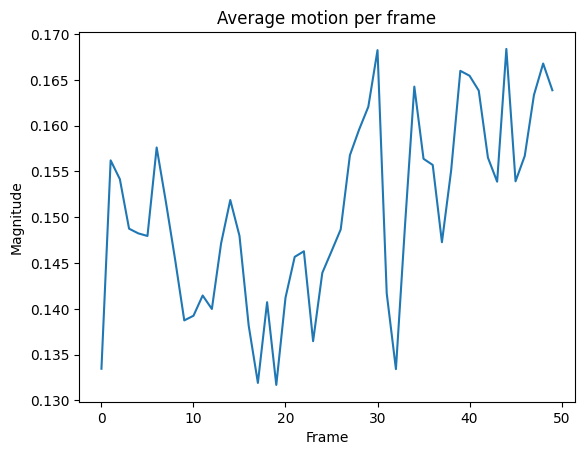

In [2]:
plt.plot(avg_magnitudes)
plt.title("Average motion per frame")
plt.xlabel("Frame")
plt.ylabel("Magnitude")



Text(0, 0.5, 'Angle')

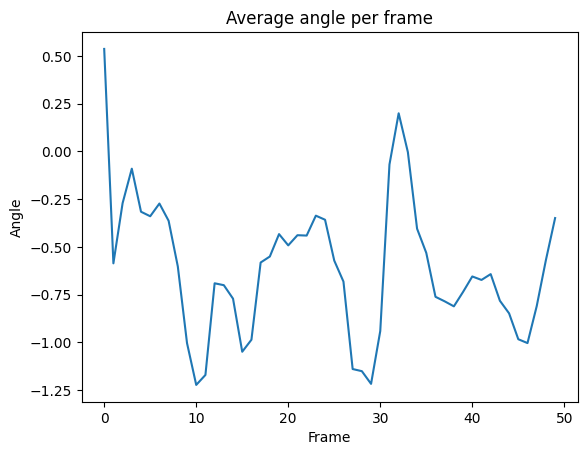

In [3]:
plt.plot(avg_angles)
plt.title("Average angle per frame")
plt.xlabel("Frame")
plt.ylabel("Angle")